# Weather vs Screen Time Analysis

**Sude Keski**  
**Student ID:** 31193

## 1. Project Idea

The goal of this project is to analyze whether weather conditions are related to screen time behavior.

In this notebook, I will:
- prepare and aggregate the screen time dataset at the **daily** level,
- collect matching historical weather data,
- merge both datasets,
- perform basic EDA,
- test a few simple hypotheses.

In [ ]:
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from scipy.stats import ttest_ind, pearsonr

## 2. Load Screen Time Dataset

Initially, this project was planned to use personal screen time data collected from an iPhone. However, due to platform limitations (Apple does not allow access to historical screen time data), this approach was not feasible.

Instead, a publicly available dataset from Kaggle is used. This dataset contains mobile screen time and app usage data over a period from January to April 2024.
https://www.kaggle.com/datasets/khushikyad001/screen-time-and-app-usage-dataset-iosandroid?resource=download

The dataset is associated with a user located in Greater Noida, Uttar Pradesh, India. Therefore, weather data from this location is collected and used to enrich the analysis.
https://www.kaggle.com/khushikyad001

In [ ]:
df = pd.read_csv("screen_time_app_usage_dataset.csv")
df.head()

,user_id,date,app_name,category,screen_time_min,launches,interactions,is_productive,youtube_views,youtube_likes,...,extra_col_14,extra_col_15,extra_col_16,extra_col_17,extra_col_18,extra_col_19,extra_col_20,extra_col_21,extra_col_22,extra_col_23
0,1051,2024-01-01 00:00:00.000000000,Camera,Utilities,24.53,2,7,False,NaN,NaN,...,33.43,49.03,64.74,49.49,47.64,38.34,39.56,49.14,62.18,55.91
1,1088,2024-01-01 00:43:41.673891297,Chrome,Utilities,19.78,3,2,False,NaN,NaN,...,44.06,49.40,66.63,62.10,47.64,51.88,42.35,55.86,45.96,46.69
2,1052,2024-01-01 01:27:23.347782594,Spotify,Entertainment,32.03,1,6,False,NaN,NaN,...,55.18,41.87,54.84,65.59,61.28,49.51,41.11,55.53,44.13,71.01
3,1028,2024-01-01 02:11:05.021673891,Google Maps,Utilities,19.10,2,5,False,NaN,NaN,...,59.39,47.87,54.68,56.14,63.98,46.75,46.98,40.15,48.11,50.09
4,1034,2024-01-01 02:54:46.695565188,Instagram,Social,25.19,1,5,False,NaN,NaN,...,51.58,60.38,51.23,44.38,52.71,58.19,37.47,55.64,51.60,37.37


In [ ]:
# checking the structure

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (3000, 24)

Columns:
Index(['user_id', 'date', 'app_name', 'category', 'screen_time_min',
       'launches', 'interactions', 'is_productive', 'youtube_views',
       'youtube_likes', 'youtube_comments', 'extra_col_11', 'extra_col_12',
       'extra_col_13', 'extra_col_14', 'extra_col_15', 'extra_col_16',
       'extra_col_17', 'extra_col_18', 'extra_col_19', 'extra_col_20',
       'extra_col_21', 'extra_col_22', 'extra_col_23'],
      dtype='object')


## 3. Data Preparation

For this project, I use the main columns that are directly related to app usage:
- `date`
- `category`
- `screen_time_min`
- `launches`
- `interactions`
- `is_productive`

Then I aggregate the rows by **day** and turn app categories into separate columns.

In [ ]:
# only needed columns

screen_df = df[[
    "date",
    "category",
    "screen_time_min",
    "launches",
    "interactions",
    "is_productive"
]].copy()

screen_df["date"] = pd.to_datetime(screen_df["date"]).dt.floor("D")
screen_df.head()

,date,category,screen_time_min,launches,interactions,is_productive
0,2024-01-01,Utilities,24.53,2,7,False
1,2024-01-01,Utilities,19.78,3,2,False
2,2024-01-01,Entertainment,32.03,1,6,False
3,2024-01-01,Utilities,19.10,2,5,False
4,2024-01-01,Social,25.19,1,5,False


In [ ]:
# aggregating screen time by day, category

daily_category = (
    screen_df.groupby(["date", "category"])["screen_time_min"]
    .sum()
    .reset_index()
)

daily_pivot = (
    daily_category.pivot(index="date", columns="category", values="screen_time_min")
    .fillna(0)
)

daily_pivot.columns = [str(col).lower().replace(" ", "_") for col in daily_pivot.columns]
daily_pivot = daily_pivot.reset_index()

daily_pivot.head()

,date,entertainment,productivity,social,utilities
0,2024-01-01,57.90,133.06,472.95,269.12
1,2024-01-02,162.31,61.79,184.63,298.06
2,2024-01-03,166.32,91.96,300.43,263.80
3,2024-01-04,108.23,217.46,222.54,290.71
4,2024-01-05,324.03,122.40,171.63,373.60


In [ ]:
# additional daily features

daily_summary = (
    screen_df.groupby("date")
    .agg(
        total_screen_time_min=("screen_time_min", "sum"),
        total_launches=("launches", "sum"),
        total_interactions=("interactions", "sum"),
        productive_app_share=("is_productive", "mean")
    )
    .reset_index()
)

daily_screen = daily_summary.merge(daily_pivot, on="date", how="left")
daily_screen.head()

,date,total_screen_time_min,total_launches,total_interactions,productive_app_share,entertainment,productivity,social,utilities
0,2024-01-01,933.03,83,151,0.151515,57.90,133.06,472.95,269.12
1,2024-01-02,706.79,74,172,0.090909,162.31,61.79,184.63,298.06
2,2024-01-03,822.51,72,183,0.060606,166.32,91.96,300.43,263.80
3,2024-01-04,838.94,62,166,0.363636,108.23,217.46,222.54,290.71
4,2024-01-05,991.66,67,150,0.181818,324.03,122.40,171.63,373.60


## 4. Collect Historical Weather Data

I use the **Open-Meteo Historical Weather API** for:
- **Location:** Greater Noida, Uttar Pradesh, India
- **Period:** January 1, 2024 to April 30, 2024

The weather features used in this notebook are:
- mean daily temperature
- rain sum
- precipitation sum
- weather code

In [ ]:
# historical weather data from Open-Meteo

latitude = 28.4744
longitude = 77.5040

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={latitude}"
    f"&longitude={longitude}"
    "&start_date=2024-01-01"
    "&end_date=2024-04-30"
    "&daily=temperature_2m_mean,precipitation_sum,rain_sum,weather_code"
    "&timezone=auto"
)

response = requests.get(url)
weather_json = response.json()

weather_df = pd.DataFrame({
    "date": weather_json["daily"]["time"],
    "temperature_mean": weather_json["daily"]["temperature_2m_mean"],
    "precipitation_sum": weather_json["daily"]["precipitation_sum"],
    "rain_sum": weather_json["daily"]["rain_sum"],
    "weather_code": weather_json["daily"]["weather_code"],
})

weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df["is_rainy"] = (weather_df["rain_sum"] > 0).astype(int)

weather_df.head()

,date,temperature_mean,precipitation_sum,rain_sum,weather_code,is_rainy
0,2024-01-01,10.4,0.0,0.0,3,0
1,2024-01-02,9.1,0.0,0.0,3,0
2,2024-01-03,9.9,0.0,0.0,3,0
3,2024-01-04,11.9,0.0,0.0,3,0
4,2024-01-05,12.3,0.1,0.1,51,1


## 5. Merge Screen Time Data with Weather Data

After preparing both datasets, I merge them by `date`.

In [ ]:
# merging datasets

final_df = pd.merge(daily_screen, weather_df, on="date", how="inner")
final_df.head()

,date,total_screen_time_min,total_launches,total_interactions,productive_app_share,entertainment,productivity,social,utilities,temperature_mean,precipitation_sum,rain_sum,weather_code,is_rainy
0,2024-01-01,933.03,83,151,0.151515,57.90,133.06,472.95,269.12,10.4,0.0,0.0,3,0
1,2024-01-02,706.79,74,172,0.090909,162.31,61.79,184.63,298.06,9.1,0.0,0.0,3,0
2,2024-01-03,822.51,72,183,0.060606,166.32,91.96,300.43,263.80,9.9,0.0,0.0,3,0
3,2024-01-04,838.94,62,166,0.363636,108.23,217.46,222.54,290.71,11.9,0.0,0.0,3,0
4,2024-01-05,991.66,67,150,0.181818,324.03,122.40,171.63,373.60,12.3,0.1,0.1,51,1


In [ ]:
# overview of the merged dataset

print("Final shape:", final_df.shape)
final_df.info()

Final shape: (92, 14)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 92 entries, 0 to 91
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   92 non-null     datetime64[ns]
 1   total_screen_time_min  92 non-null     float64       
 2   total_launches         92 non-null     int64         
 3   total_interactions     92 non-null     int64         
 4   productive_app_share   92 non-null     float64       
 5   entertainment          92 non-null     float64       
 6   productivity           92 non-null     float64       
 7   social                 92 non-null     float64       
 8   utilities              92 non-null     float64       
 9   temperature_mean       92 non-null     float64       
 10  precipitation_sum      92 non-null     float64       
 11  rain_sum               92 non-null     float64       
 12  weather_code           92 non-null     int64

## 6. Exploratory Data Analysis (EDA)

In this section, I explore:
- the daily trend of total screen time,
- the relationship between temperature and screen time,
- differences between rainy and non-rainy days,
- correlations between variables.

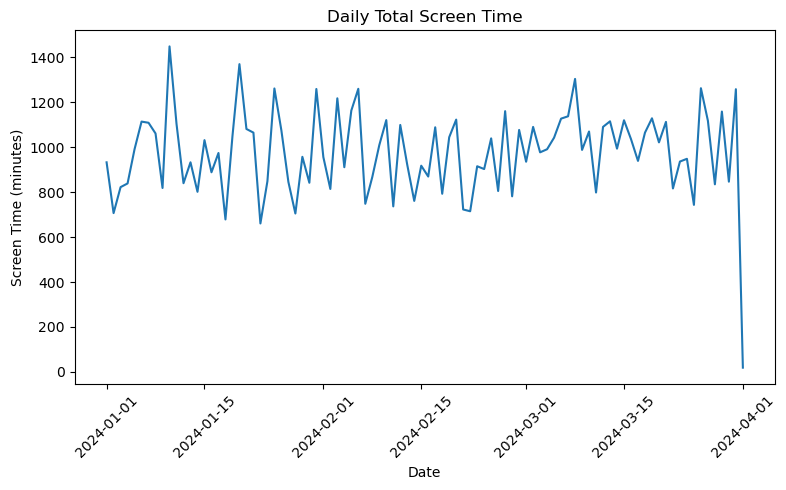

In [ ]:
# Daily total screen time

plt.plot(final_df["date"], final_df["total_screen_time_min"])
plt.title("Daily Total Screen Time")
plt.xlabel("Date")
plt.ylabel("Screen Time (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The last observation had an unusually low screen time value, likely due to incomplete or missing data.

To ensure consistency, this observation was removed before analysis.

In [24]:
# remove last row
final_df = final_df.iloc[:-1]

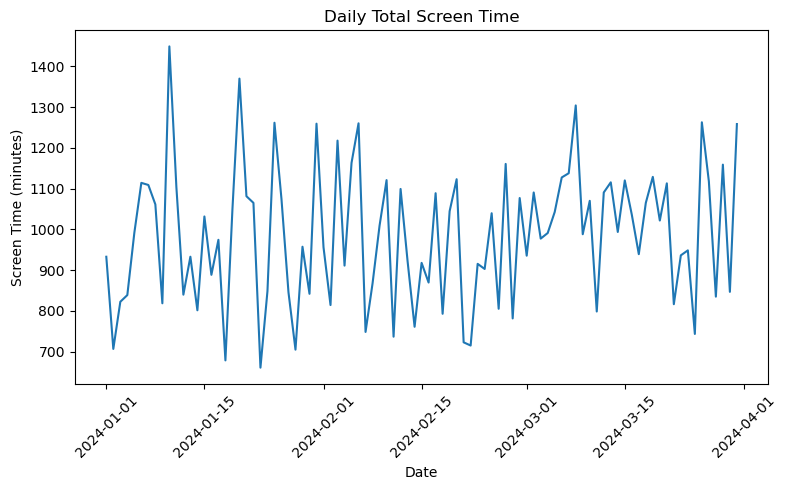

In [ ]:
# Daily total screen time

plt.plot(final_df["date"], final_df["total_screen_time_min"])
plt.title("Daily Total Screen Time")
plt.xlabel("Date")
plt.ylabel("Screen Time (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

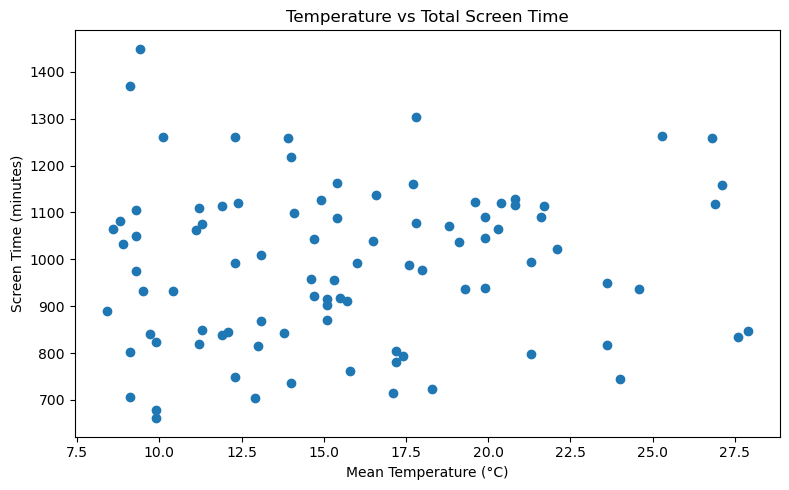

In [ ]:
# Temperature vs total screen time

plt.scatter(final_df["temperature_mean"], final_df["total_screen_time_min"])
plt.title("Temperature vs Total Screen Time")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Screen Time (minutes)")
plt.tight_layout()
plt.show()

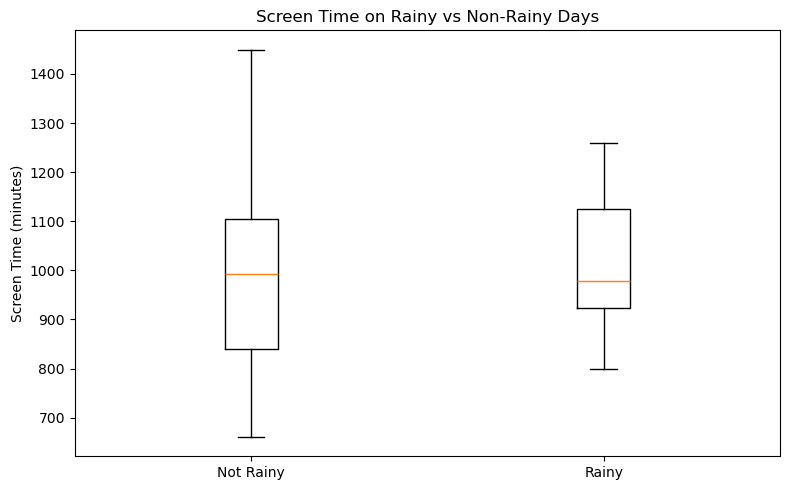

In [ ]:
# Rainy vs non-rainy days

rainy = final_df[final_df["is_rainy"] == 1]["total_screen_time_min"]
not_rainy = final_df[final_df["is_rainy"] == 0]["total_screen_time_min"]

plt.boxplot([not_rainy, rainy], labels=["Not Rainy", "Rainy"])
plt.title("Screen Time on Rainy vs Non-Rainy Days")
plt.ylabel("Screen Time (minutes)")
plt.tight_layout()
plt.show()

In [ ]:
# correlation table

numeric_cols = final_df.select_dtypes(include=["number"]).columns
corr_df = final_df[numeric_cols].corr()

corr_df[["total_screen_time_min"]].sort_values(by="total_screen_time_min", ascending=False)

,total_screen_time_min
total_screen_time_min,1.000000
productivity,0.482589
entertainment,0.413075
social,0.356690
productive_app_share,0.197522
utilities,0.161381
temperature_mean,0.084919
total_interactions,0.064393
is_rainy,0.061769
weather_code,0.059048


## 7. Hypothesis Tests

### Hypothesis Test 1
- **H0:** Rainy days do not change total screen time.
- **H1:** Rainy days change total screen time.

### Hypothesis Test 2
- **H0:** Temperature has no linear relationship with total screen time.
- **H1:** Temperature has a linear relationship with total screen time.

In [ ]:
# T-test for rainy vs non-rainy days

t_stat, p_value = ttest_ind(rainy, not_rainy, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0. There is a significant difference.")
else:
    print("Result: Fail to reject H0. There is no significant difference.")

T-statistic: 0.692721768411952
P-value: 0.4992887301346779
Result: Fail to reject H0. There is no significant difference.


In [ ]:
# Correlation test for temperature and total screen time

corr_value, corr_p = pearsonr(final_df["temperature_mean"], final_df["total_screen_time_min"])

print("Pearson correlation:", corr_value)
print("P-value:", corr_p)

if corr_p < 0.05:
    print("Result: Reject H0. There is a significant linear relationship.")
else:
    print("Result: Fail to reject H0. There is no significant linear relationship.")

Pearson correlation: 0.08491914369716536
P-value: 0.42352211769034404
Result: Fail to reject H0. There is no significant linear relationship.
